In [1]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

In [2]:
df = pd.read_excel('skin_irritation.xlsx', sheet_name='Data_invivo')

In [3]:
df.columns = df.columns.str.strip()

In [4]:
df = df[
    (df['Mixture'] == 'Chemical') &
    (df['Species'] == 'Human') &
    (df['Endpoint'] == 'Positive reaction')
    ]

In [5]:
df = df[['SMILES', 'Response']].dropna()
df.columns = ['smiles', 'y']

In [8]:
def standardize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles, sanitize = True)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

df['smiles'] = df['smiles'].apply(standardize_smiles)

print("valid smiles:", df["smiles"].notna().sum())

df = df.dropna()
print("after dropna:", df.shape)

valid smiles: 69
after dropna: (69, 2)


In [10]:
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna(subset=['y'])

In [11]:
grouped = df.groupby('smiles')['y']

clean_data = []

for smiles, values in grouped:
    if len(values) == 1:
        clean_data.append([smiles, values.iloc[0]])
    else:
        if values.max() - values.min() < 10:  # 기준 (직접 설정)
            clean_data.append([smiles, values.mean()])
        # 차이 크면 제거

df_clean = pd.DataFrame(clean_data, columns=['smiles', 'y'])

In [44]:
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }

desc_list = []

for s in df_clean['smiles']:
    try:
        desc_list.append(calc_descriptors(s))
    except:
        desc_list.append({
        'MolWt': None,
        'LogP': None,
        'TPSA': None,
        'NumHDonors': None,
        'NumHAcceptors': None,
        'NumRotatableBonds': None
    })

desc_df = pd.DataFrame(desc_list)

df_final = pd.concat([df_clean.reset_index(drop=True), desc_df], axis=1)
df_final = df_final.dropna()

In [45]:
results = []

for col in ['MolWt', 'LogP', 'TPSA']:
    X = df_final[[col]]
    y = df_final['y']

    model = LinearRegression()
    model.fit(X, y)
    pred = model.predict(X)

    r2 = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae = mean_absolute_error(y, pred)
    nrmse = rmse / (y.max() - y.min())
    spearman = spearmanr(y, pred)[0]
    results.append([col, r2, rmse, mae, nrmse, spearman])

result_df = pd.DataFrame(results, columns=['descriptor', 'R2', 'RMSE', 'MAE', 'NRMSE', 'Spearman'])

print(result_df)

  descriptor        R2       RMSE        MAE     NRMSE  Spearman
0      MolWt  0.104739  24.172604  17.611735  0.241726  0.362695
1       LogP  0.000888  25.536168  18.934006  0.255362  0.181165
2       TPSA  0.008071  25.444207  18.611813  0.254442  0.080832


In [46]:
best = result_df.sort_values(by='R2', ascending=False).iloc[0]
print("\nBest descriptor:", best['descriptor'])


Best descriptor: MolWt


In [47]:
X = df_final[[best['descriptor']]]
y = df_final['y']

model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)

print("\nFinal Model Performance")
print("R2:", r2_score(y, pred))
print("RMSE:", np.sqrt(mean_squared_error(y, pred)))
print("MAE:", mean_absolute_error(y, pred))
print("Spearman:", spearmanr(y, pred)[0])


Final Model Performance
R2: 0.10473943055540436
RMSE: 24.172603645502683
MAE: 17.611735026041053
Spearman: 0.3626954448529087


In [48]:
# 독성 높은 TOP 10
print(df_clean.sort_values(by='y', ascending=False).head(10))

# 독성 낮은 TOP 10
print(df_clean.sort_values(by='y', ascending=True).head(10))

             smiles      y
42          CS(C)=O  100.0
12      CC(O)C(=O)O   80.8
20    CCCCCCCC(=O)O   76.2
22  CCCCCCCCCC(=O)O   74.5
21   CCCCCCCCC(=O)O   65.5
18     CCCCCCC(=O)O   64.5
57      [Na+].[OH-]   59.4
19        CCCCCCC=O   58.6
17         CCCCCCBr   53.3
44     Cc1c[nH]nc1C   37.9
                         smiles    y
0      *C.*C.O=S(=O)(O)c1ccccc1  0.0
1                 *C.*C.OCCOCCO  0.0
2              C=C(C)C(=O)OCCCC  0.0
4   C=CCCC(=O)C1=CCCC2(CCCC2)C1  0.0
7    CC(=O)OC(C)(C)C1CC=C(C)CC1  0.0
11    CC(C)c1ccccc1C(C)c1ccccc1  0.0
10                       CC(C)O  0.0
9              CC(C)=CCCC(C)CCO  0.0
14              CC(O)COC(C)(C)C  0.0
15         CC1=CCC(C(C)(C)O)CC1  0.0


In [49]:
import matplotlib.pyplot as plt

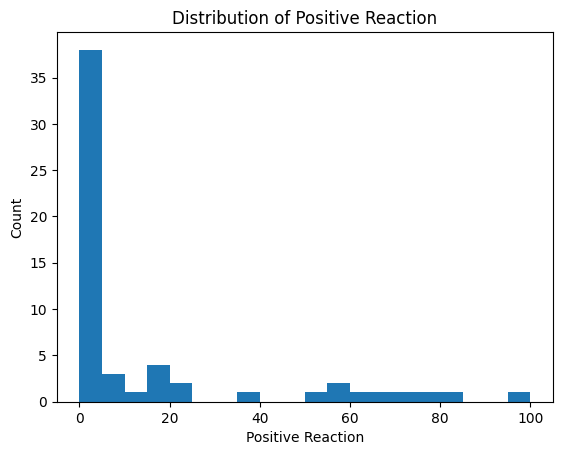

In [50]:
plt.figure()
plt.hist(df_clean['y'], bins=20)
plt.xlabel('Positive Reaction')
plt.ylabel('Count')
plt.title('Distribution of Positive Reaction')
plt.show()

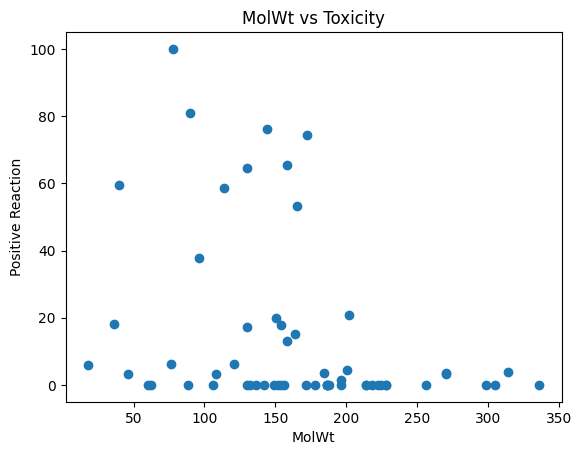

In [51]:
plt.figure()
plt.scatter(df_final['MolWt'], df_final['y'])
plt.xlabel('MolWt')
plt.ylabel('Positive Reaction')
plt.title('MolWt vs Toxicity')
plt.show()

In [52]:
threshold = 15
df_final['y_class'] = (df_final['y'] > threshold).astype(int)

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef

X = df_final[[best['descriptor']]]
y = df_final['y_class']

model = LogisticRegression()
model.fit(X, y)

pred = model.predict(X)
prob = model.predict_proba(X)[:, 1]

In [54]:
cm = confusion_matrix(y, pred)

acc = accuracy_score(y, pred)
recall = recall_score(y, pred)
f1 = f1_score(y, pred)
mcc = matthews_corrcoef(y, pred)
roc = roc_auc_score(y, prob)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("Recall:", recall)
print("F1-score:", f1)
print("MCC:", mcc)
print("ROC AUC:", roc)

Confusion Matrix:
 [[38  4]
 [14  2]]
Accuracy: 0.6896551724137931
Sensitivity: 0.125
Specificity: 0.9047619047619048
Recall: 0.125
F1-score: 0.18181818181818182
MCC: 0.04367853486341326
ROC AUC: 0.7172619047619048
